<a href="https://colab.research.google.com/github/nwokeochairene-blip/-Employee-Attrition-Prediction-API/blob/main/Employee_Attrition_Prediction_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importation of necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')
import kagglehub


In [2]:
df = pd.read_csv('/content/archive (4).zip')

**EXPLORATION OF MY DATA**

In [7]:
df.shape

(1470, 35)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

**EDA**

In [10]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [11]:
print("\nClass Distribution:")


Class Distribution:


In [12]:
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [13]:
df['Attrition'].value_counts(normalize=True) * 100


,proportion
Attrition,
No,83.877551
Yes,16.122449


In [14]:
plt.figure(figsize=(8,6))

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='Attrition'>

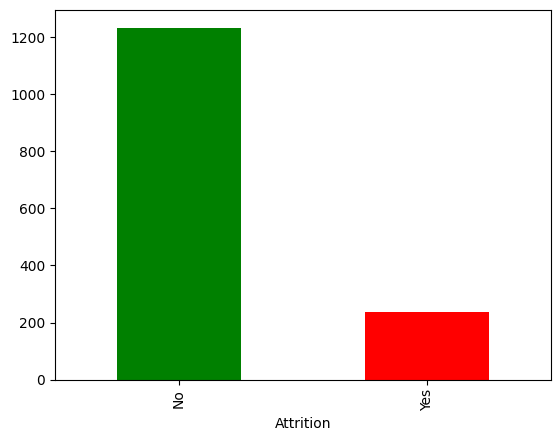

In [17]:
df['Attrition'].value_counts().plot(kind='bar', color=['green', 'red']) # visual class distibution

Text(0.5, 1.0, 'Attrition Distribution')

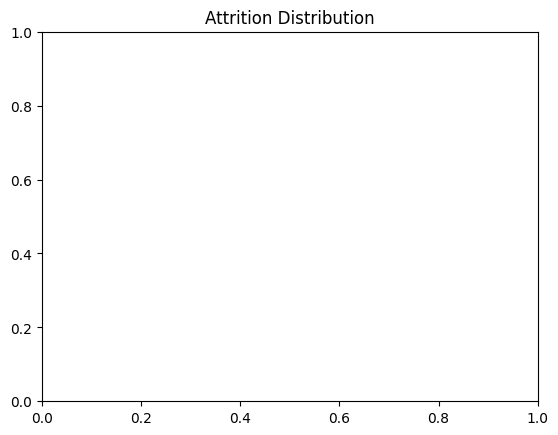

In [18]:
plt.title('Attrition Distribution')

Text(0.5, 0, 'Attrition')

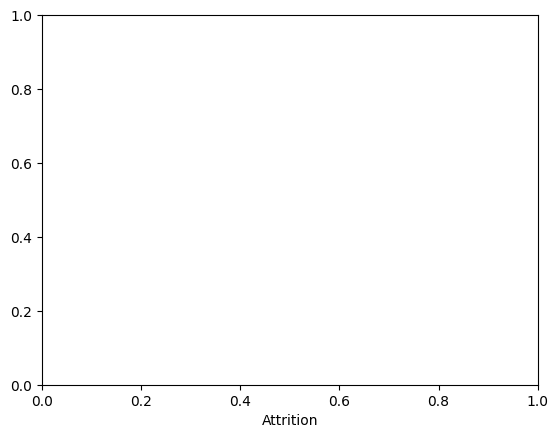

In [19]:
plt.xlabel('Attrition')

Text(0, 0.5, 'Count')

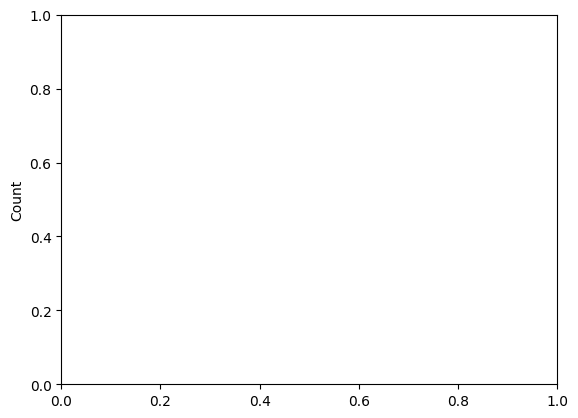

In [20]:
plt.ylabel('Count')

In [21]:
plt.show()

In [22]:
#feature relationship
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

In [23]:
categorical_features = df.select_dtypes(include=['object']).columns


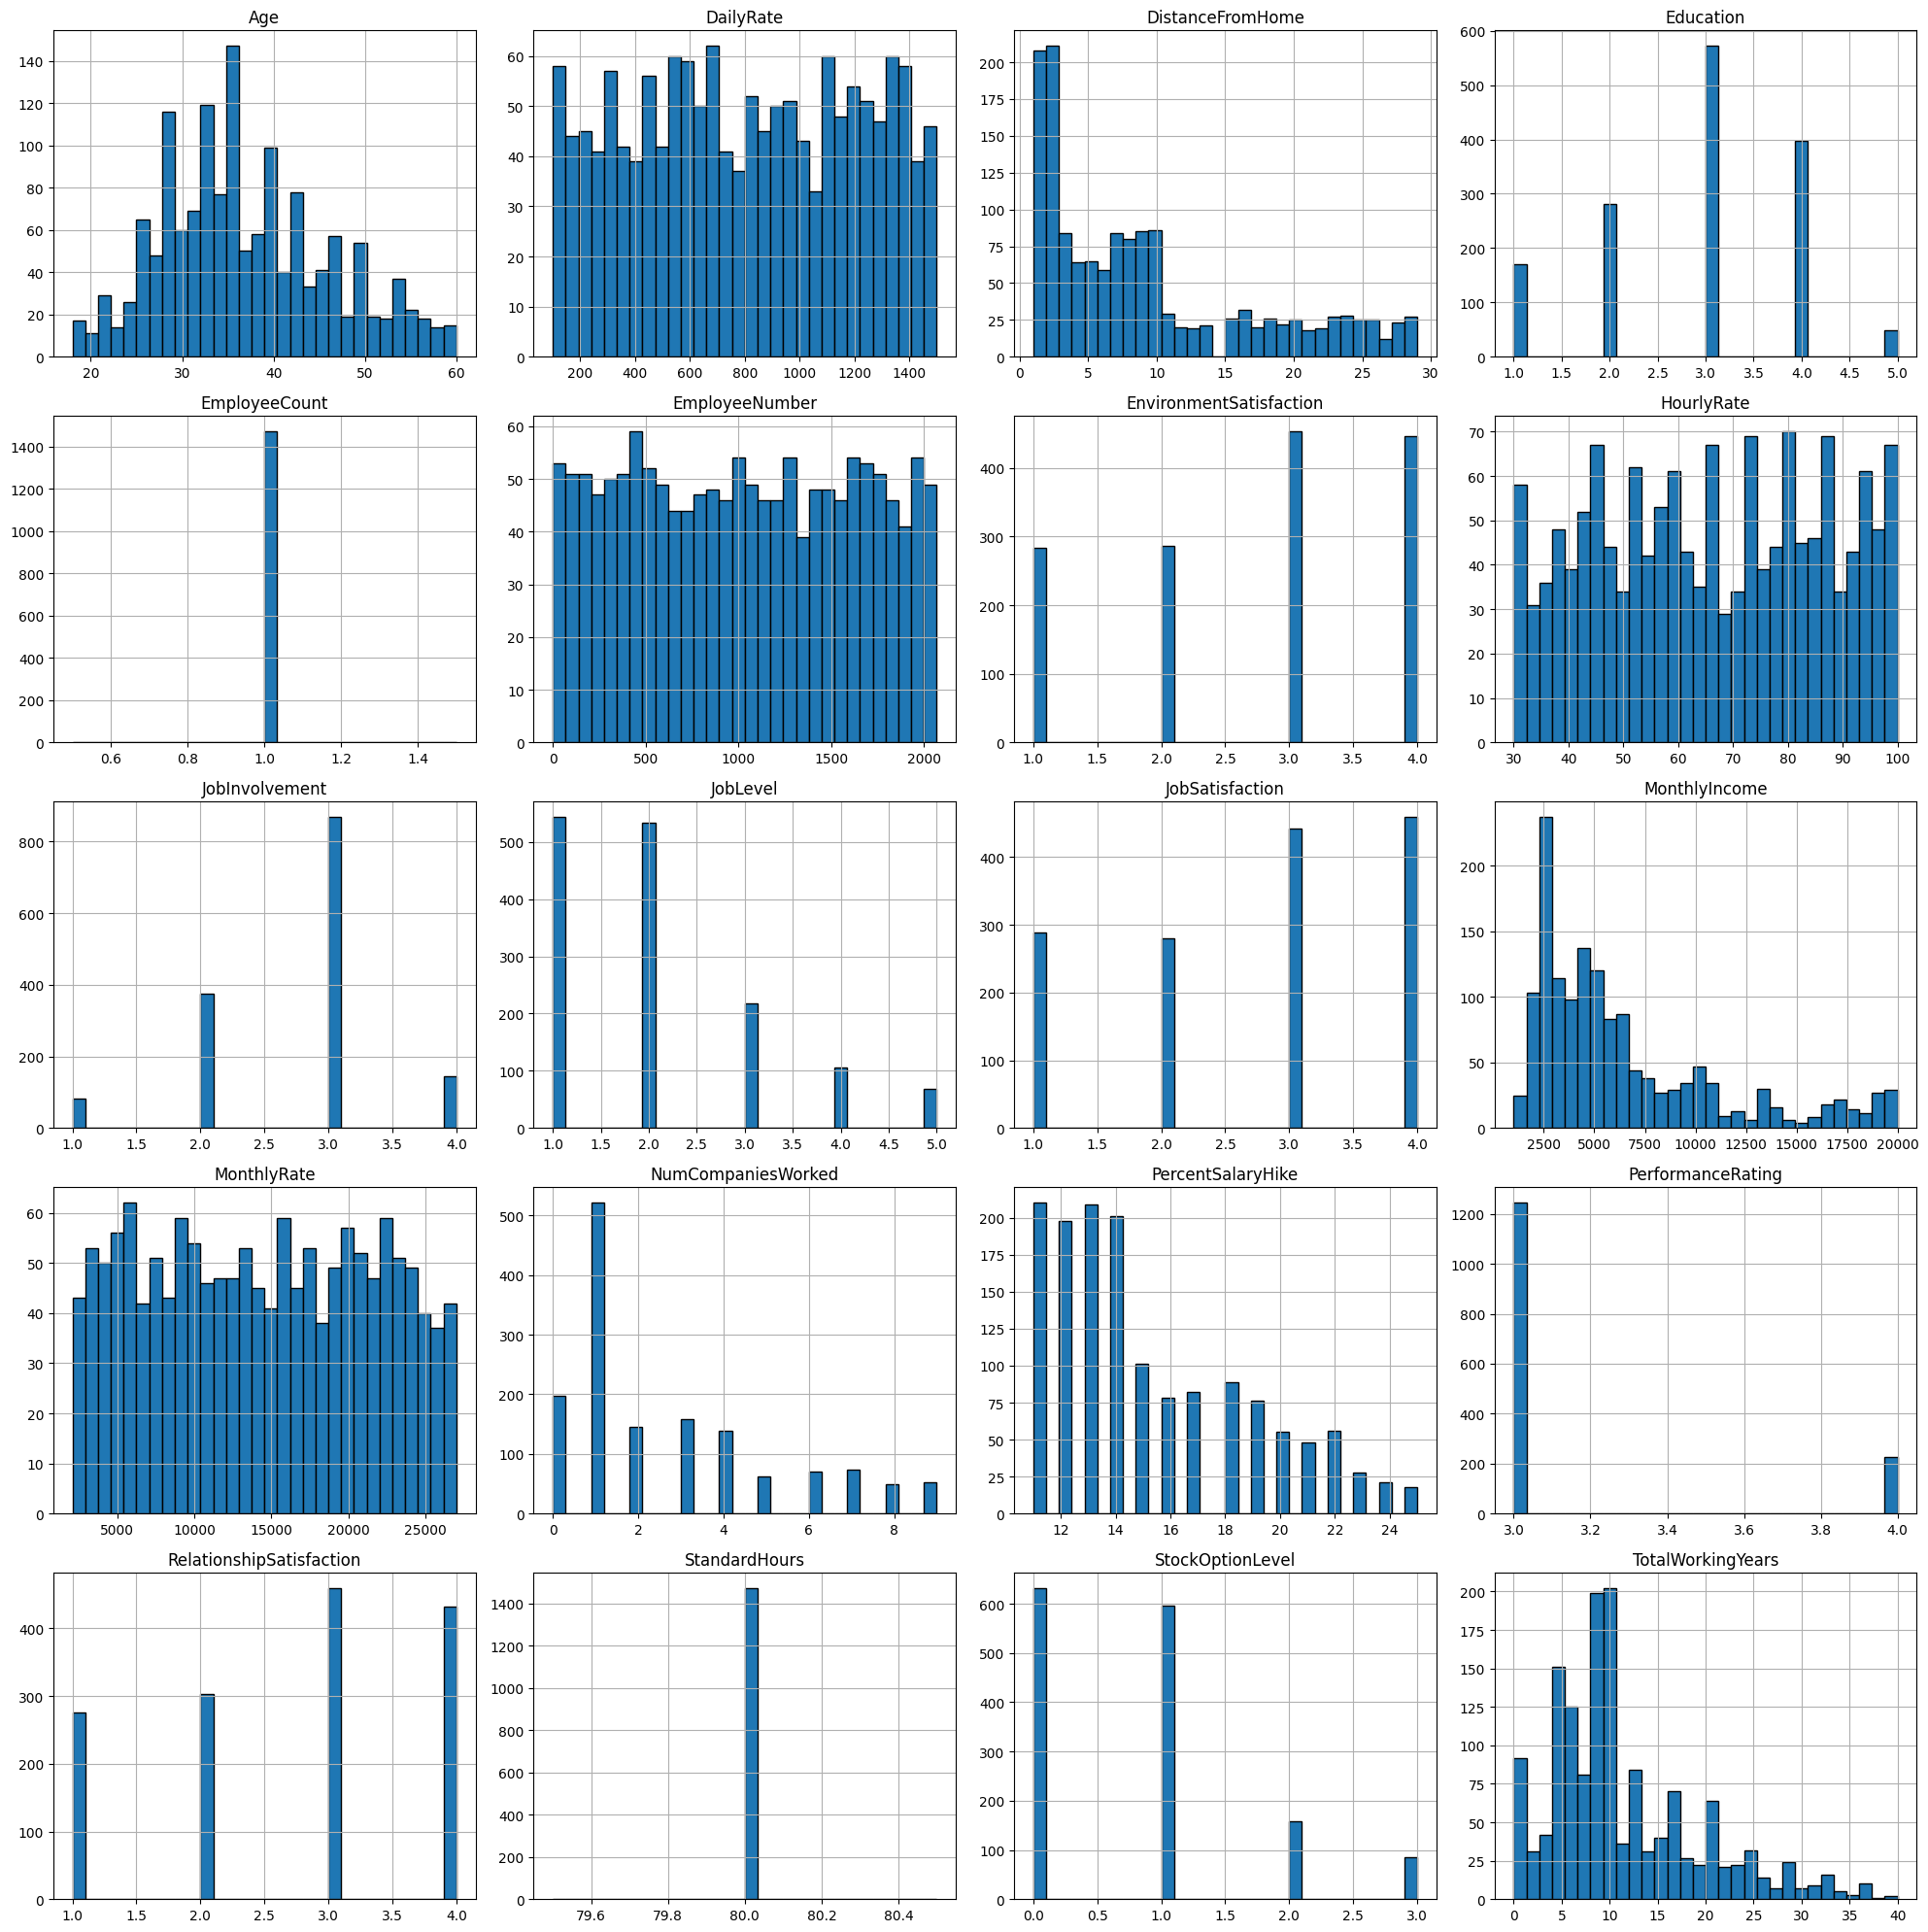

In [24]:
# Numerical feature distribution
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()
for idx, col in enumerate(numerical_features):
    if idx < 20:
        df[col].hist(ax=axes[idx], bins=30, edgecolor='black')
        axes[idx].set_title(col)
plt.tight_layout()
plt.show()


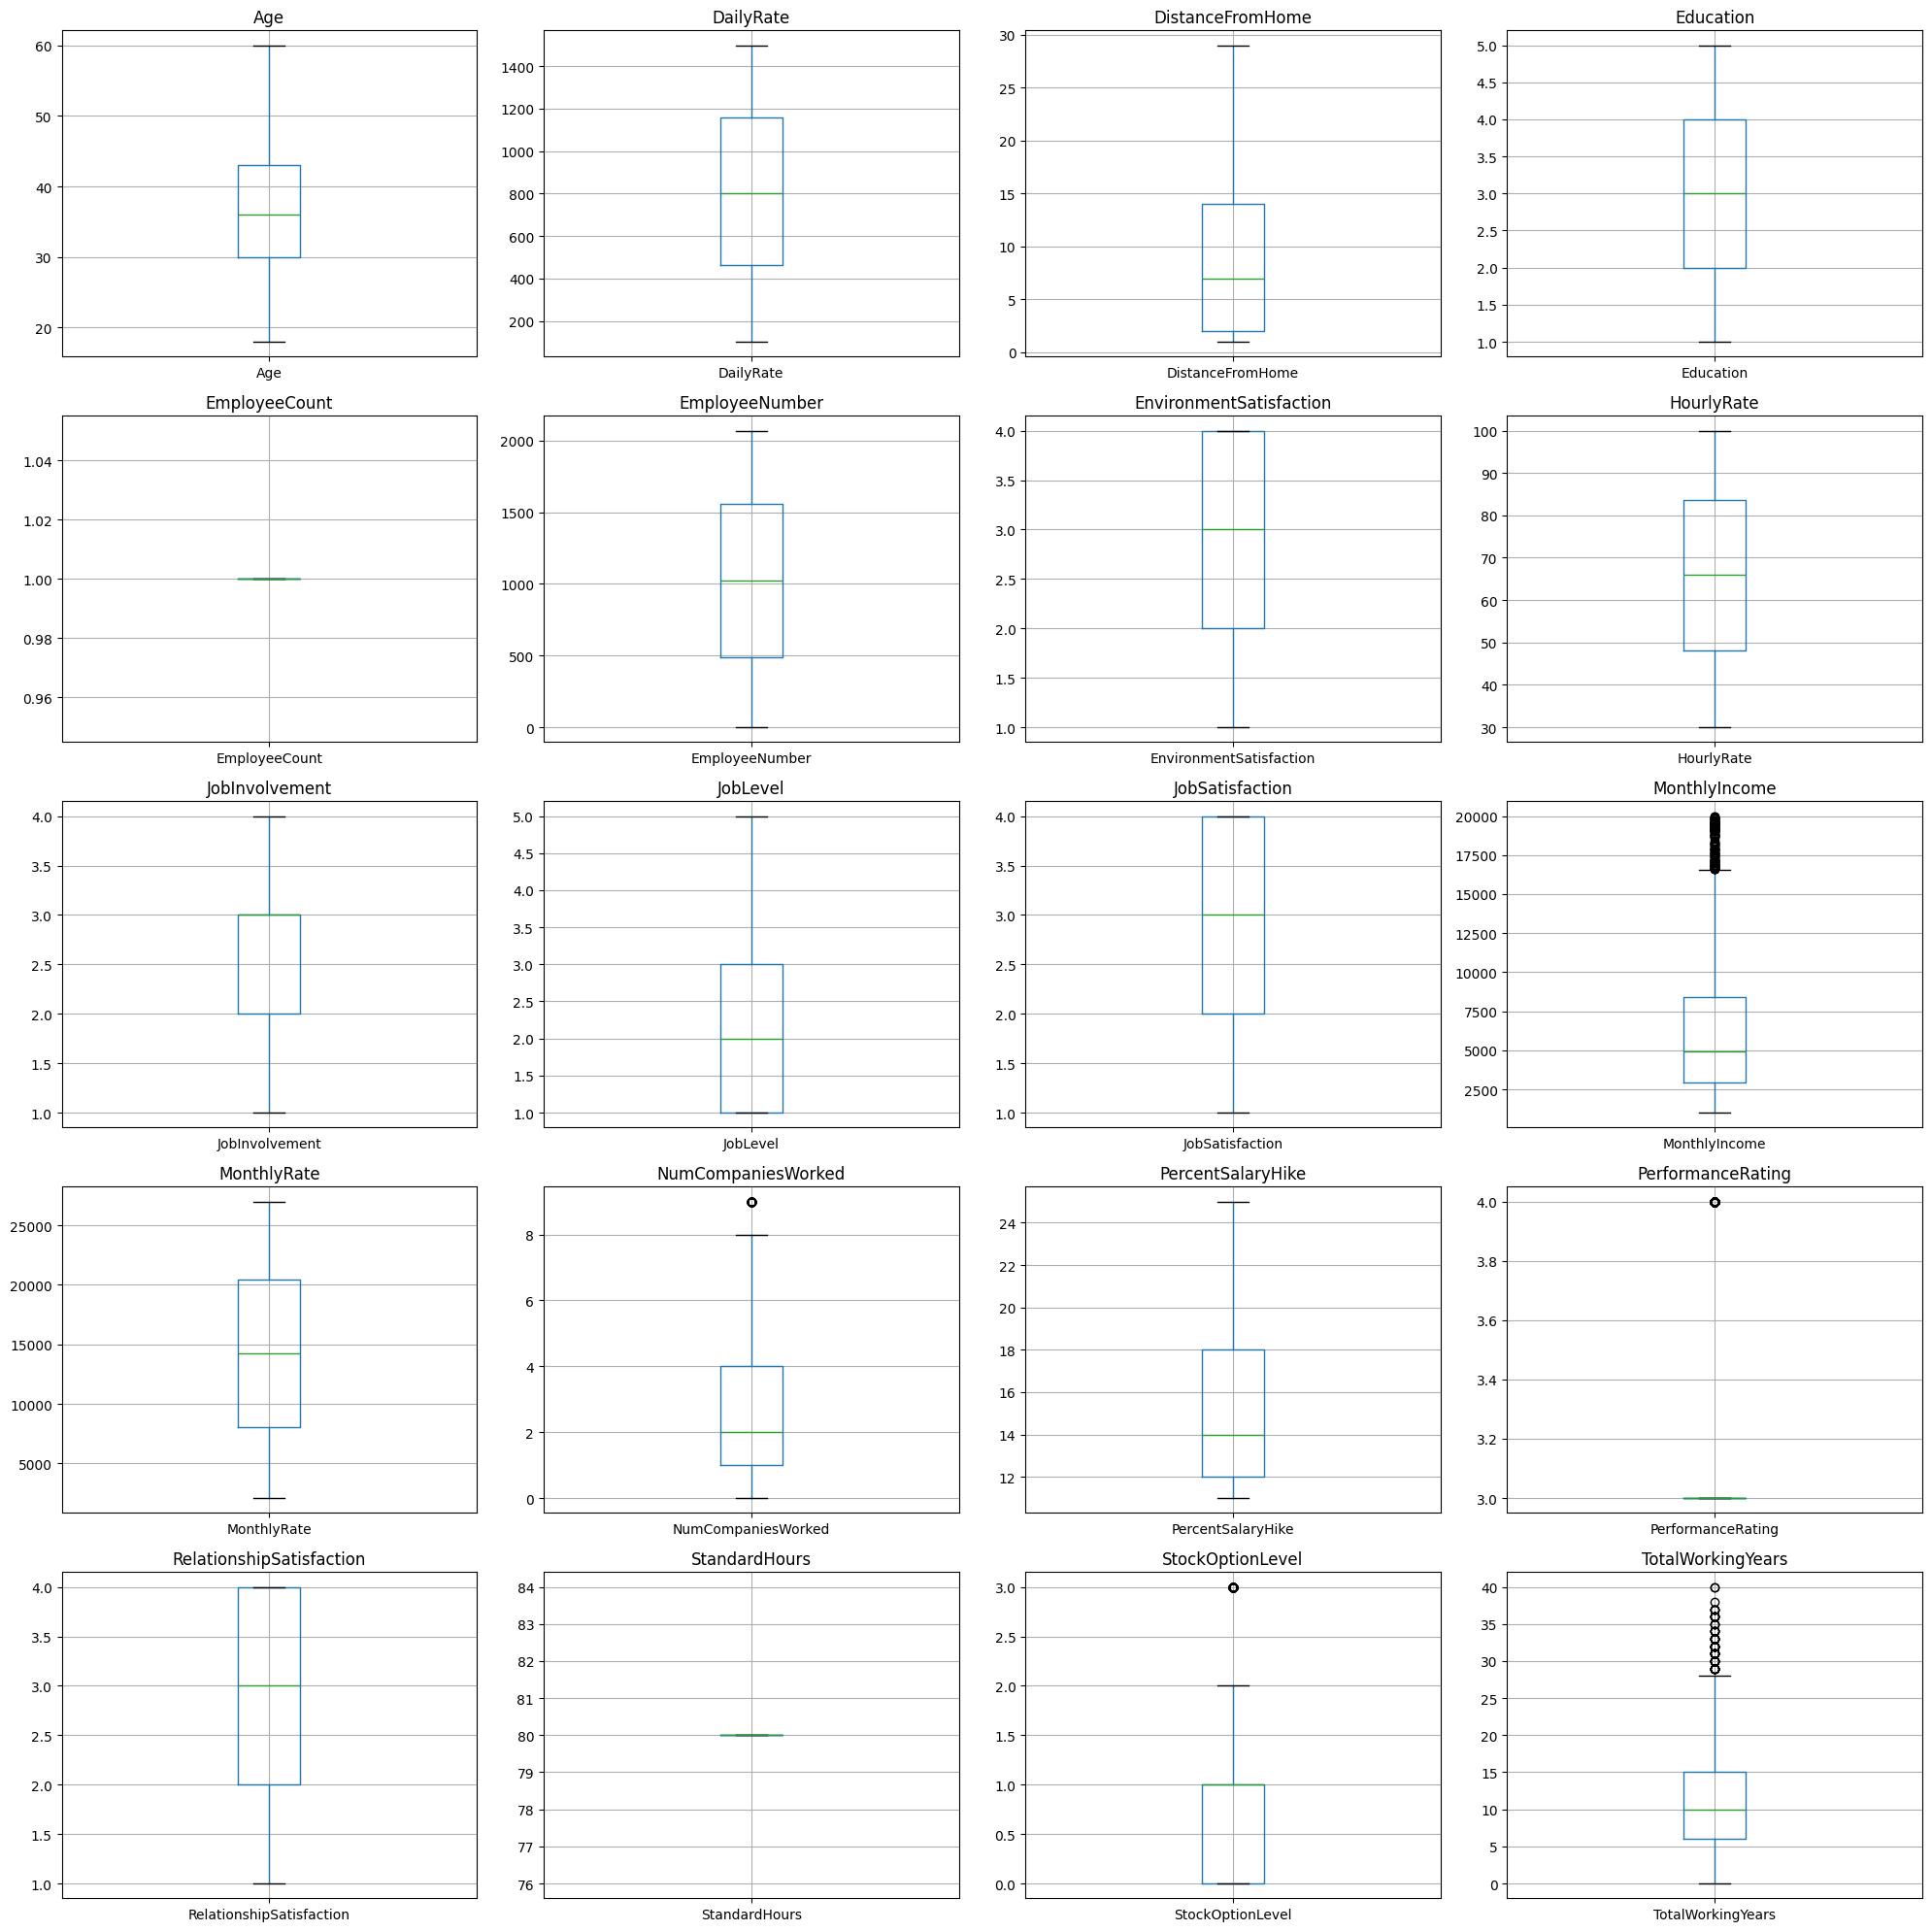

In [25]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()
for idx, col in enumerate(numerical_features):
    if idx < 20:
        df.boxplot(column=col, ax=axes[idx])
        axes[idx].set_title(col)
plt.tight_layout()
plt.show()  # Outliners, like sharing akara in a box

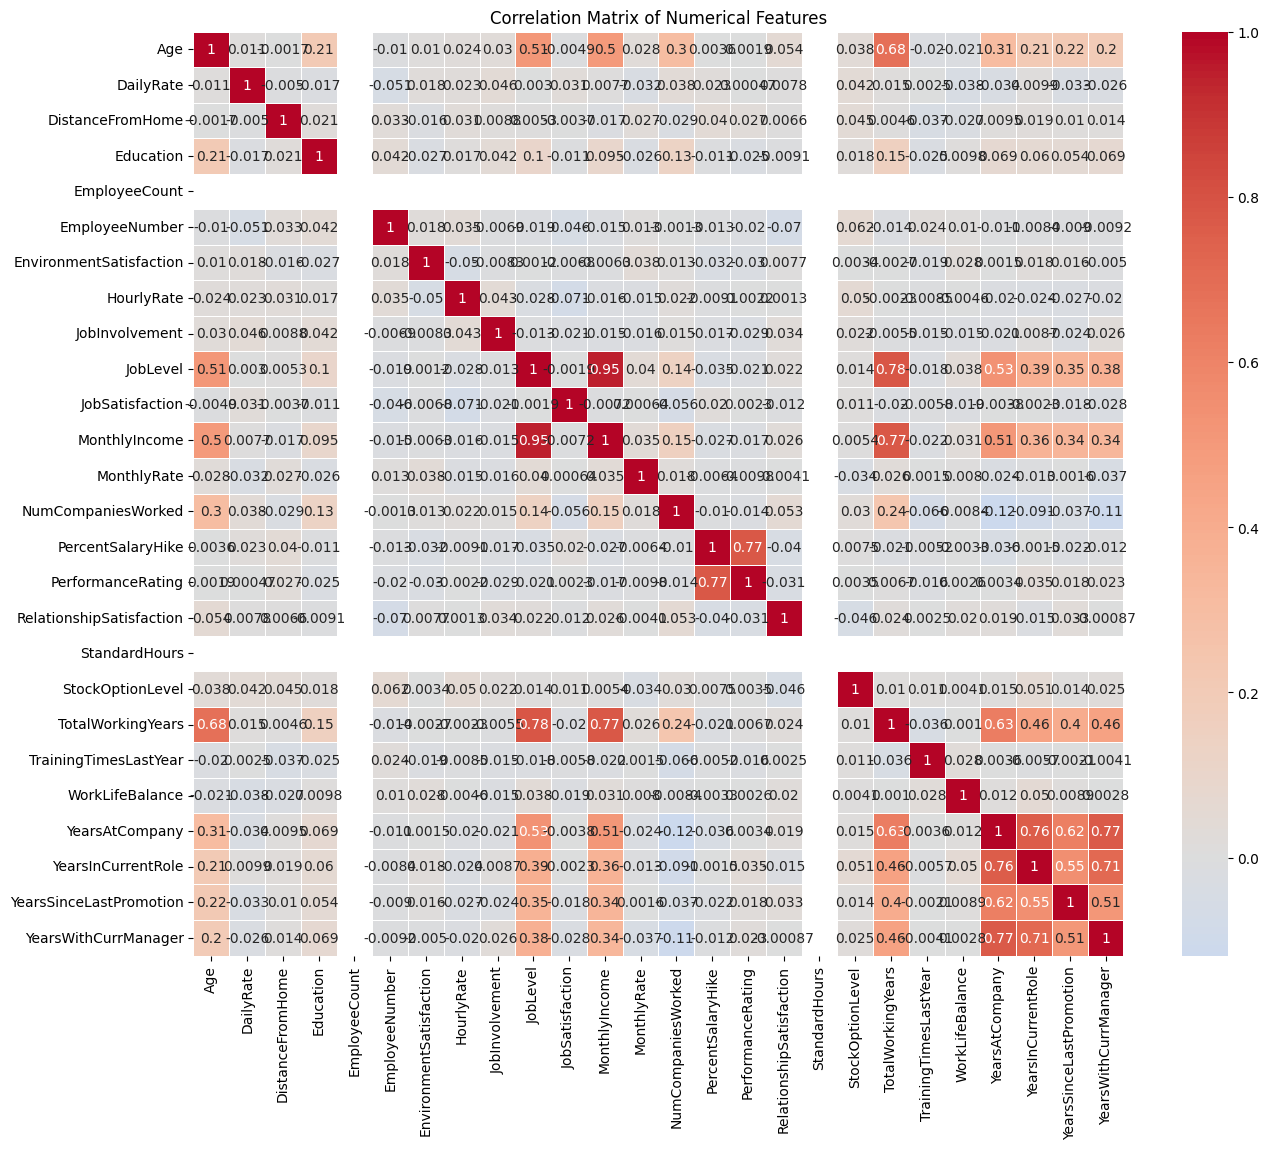

In [26]:
# Correlation Analysis
plt.figure(figsize=(15, 12))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()


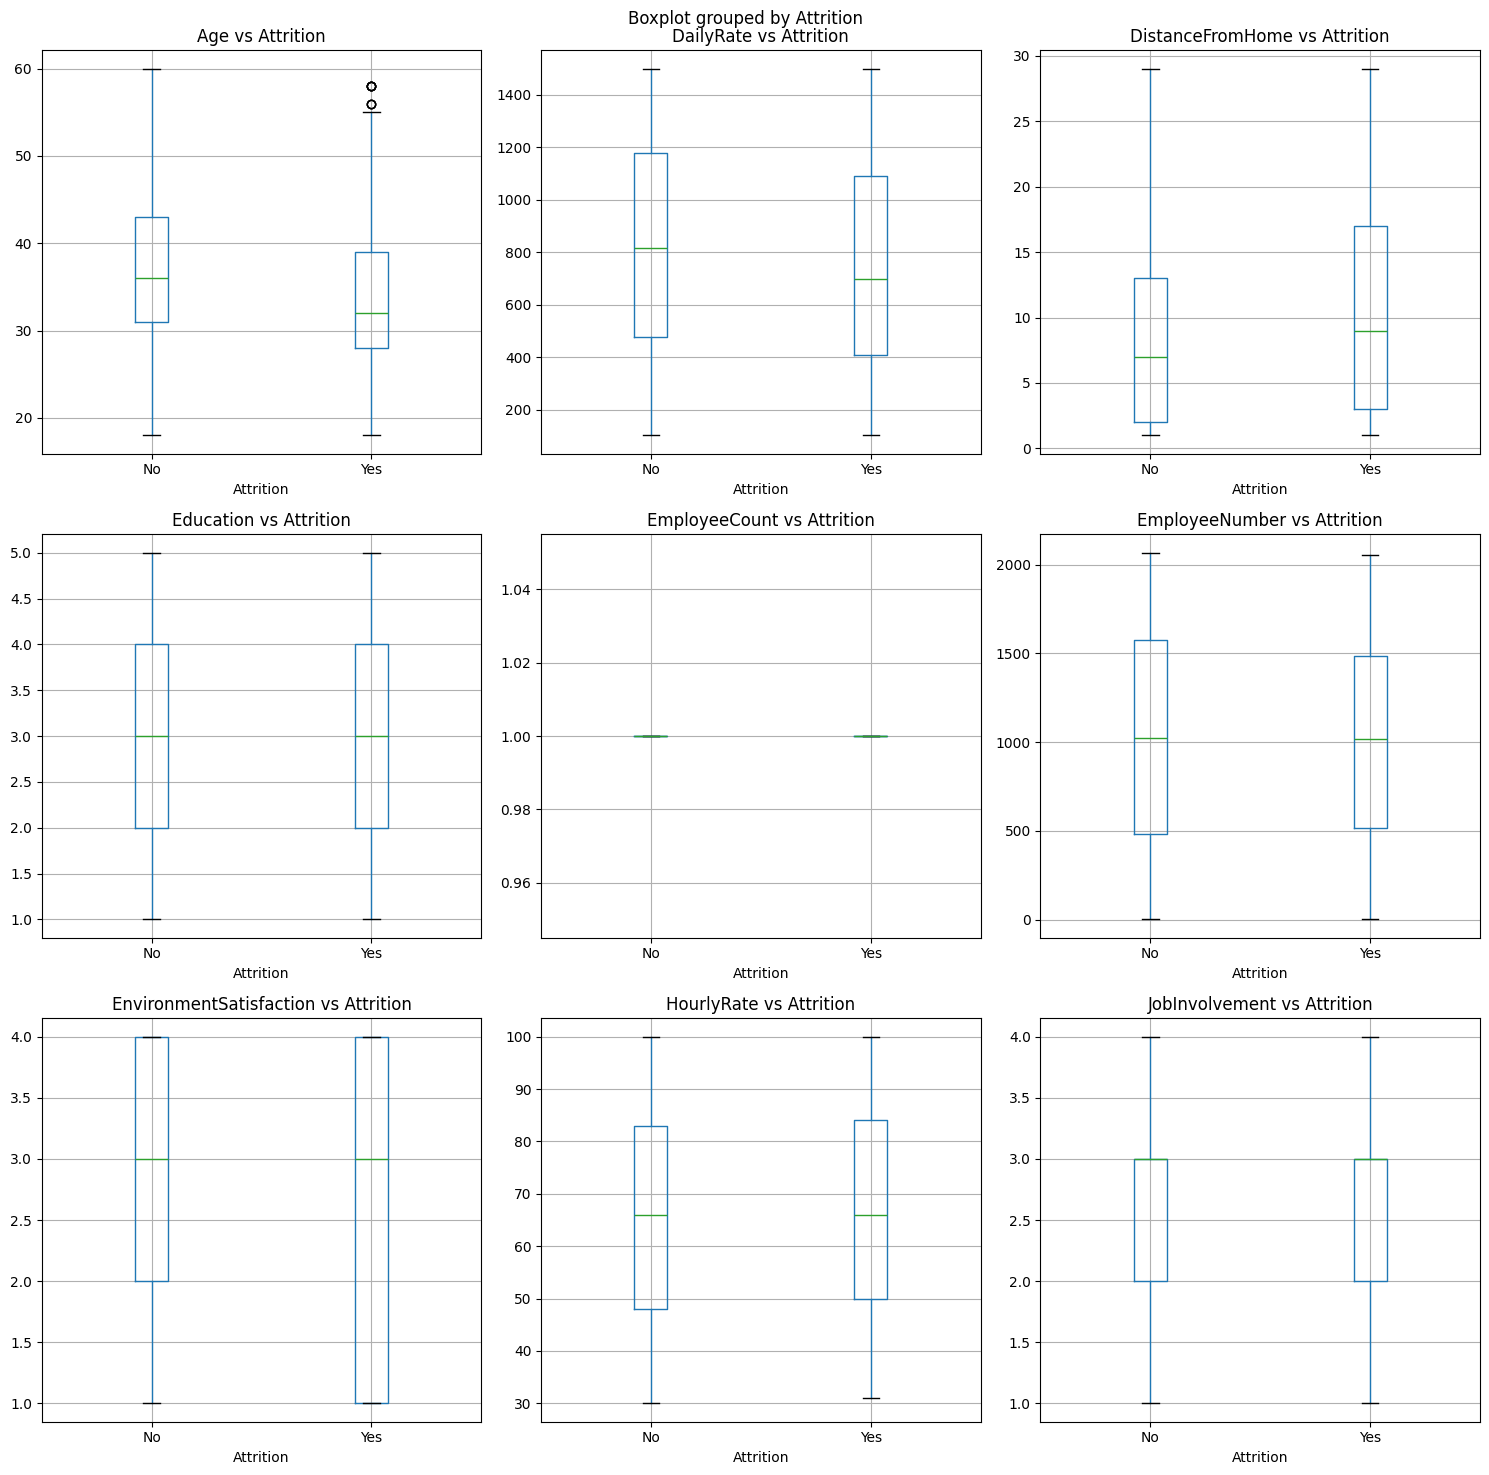

In [27]:
# Feature relationships with target
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
for idx, col in enumerate(numerical_features[:9]):
    df.boxplot(column=col, by='Attrition', ax=axes[idx])
    axes[idx].set_title(f'{col} vs Attrition')
plt.tight_layout()
plt.show()

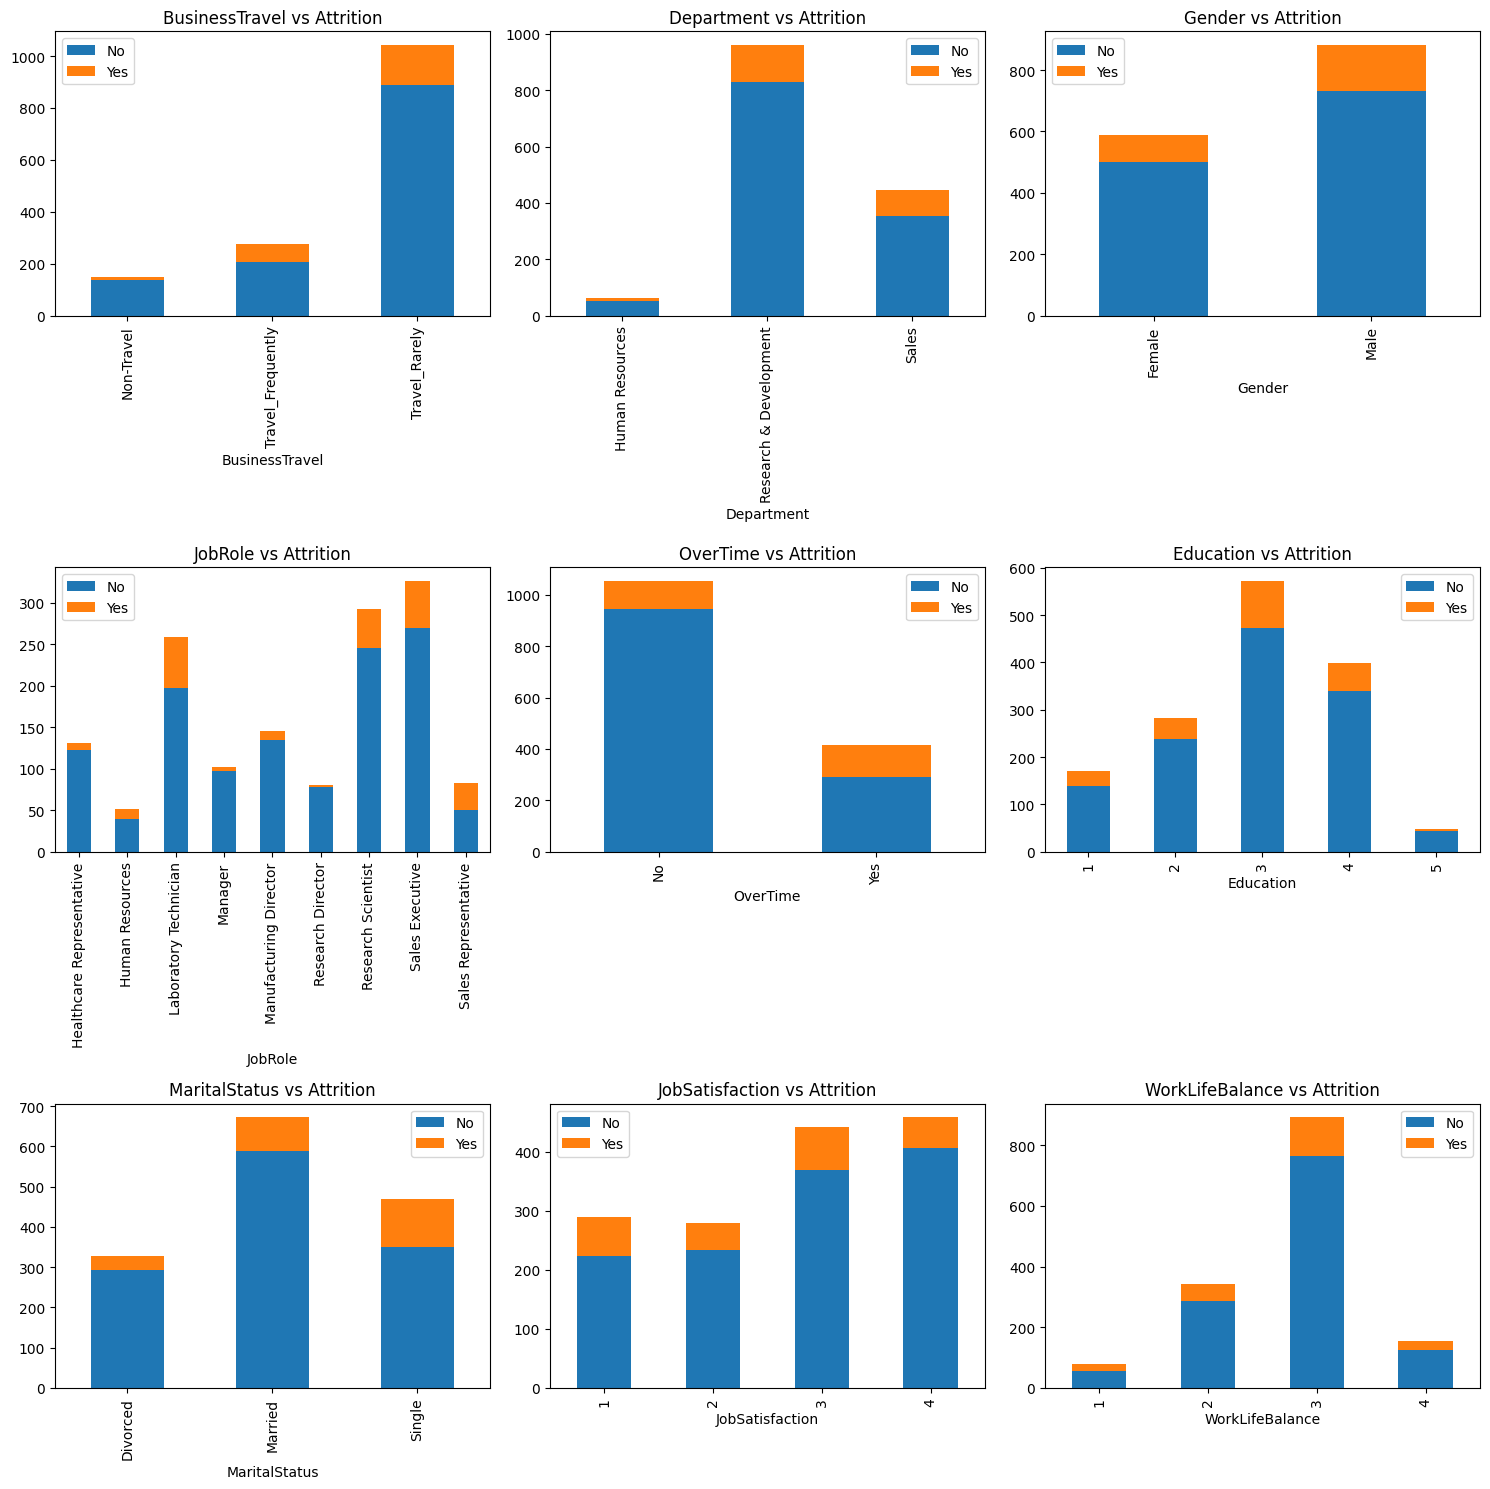

In [28]:
# Categorical features vs Attrition
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()
categorical_for_plot = ['BusinessTravel', 'Department', 'Gender', 'JobRole', 'OverTime', 'Education', 'MaritalStatus', 'JobSatisfaction', 'WorkLifeBalance']
for idx, col in enumerate(categorical_for_plot):
    if idx < 9:
        pd.crosstab(df[col], df['Attrition']).plot(kind='bar', ax=axes[idx], stacked=True)
        axes[idx].set_title(f'{col} vs Attrition')
        axes[idx].legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

*** ** DATA PREPROCESS**

In [29]:
# Separation of the feature and target
X = df.drop('Attrition', axis=1)

In [30]:
y = df['Attrition']

In [31]:
# Categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", categorical_cols)

Categorical columns to encode: Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [32]:
# Label Encoding for categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [33]:
# I dropped the low value features
features_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
X = X.drop(features_to_drop, axis=1)

In [34]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [35]:
print(f"Training set size: {X_train.shape}")

Training set size: (1176, 30)


In [36]:
print(f"Test set size: {X_test.shape}")

Test set size: (294, 30)


In [37]:
print(f"Training set class distribution:\n{y_train.value_counts()}")

Training set class distribution:
Attrition
No     986
Yes    190
Name: count, dtype: int64


In [38]:
print(f"Test set class distribution:\n{y_test.value_counts()}")

Test set class distribution:
Attrition
No     247
Yes     47
Name: count, dtype: int64


In [39]:
#Scale numerical features
scaler = StandardScaler()

In [40]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

In [41]:
X_train_scaled = X_train.copy()

In [42]:
X_test_scaled = X_test.copy()

In [43]:
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

In [44]:
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [45]:
# Convert target to binary (Yes=1, No=0)
y_train_binary = y_train.map({'Yes': 1, 'No': 0})

In [46]:
y_test_binary = y_test.map({'Yes': 1, 'No': 0})

**TRAININD OF A CLASSIFICATION MODEL**

In [48]:
#model definition
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1)
}

In [49]:
# Training and evaluation of each model
results = {}
for name, model in models.items():
    print(f"\nTraining {name}...")


Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Training LightGBM...


In [68]:
    if name in ['XGBoost', 'LightGBM']:
        X_train_use = X_train
        X_test_use = X_test
    else:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled

In [69]:
 model.fit(X_train_use, y_train_binary)

LGBMClassifier(random_state=42, verbose=-1)

In [70]:
# making prediction
y_pred = model.predict(X_test_use)


In [72]:
y_pred_proba = model.predict_proba(X_test_use)[:, 1]

In [73]:
    #Metrics calculations
    accuracy = accuracy_score(y_test_binary, y_pred)
    precision = precision_score(y_test_binary, y_pred)
    recall = recall_score(y_test_binary, y_pred)
    f1 = f1_score(y_test_binary, y_pred)

In [76]:
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Model': model
    }

    print(f"{name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_binary, y_pred))

LightGBM Results:
Accuracy: 0.8537
Precision: 0.6111
Recall: 0.2340
F1-Score: 0.3385

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.61      0.23      0.34        47

    accuracy                           0.85       294
   macro avg       0.74      0.60      0.63       294
weighted avg       0.83      0.85      0.83       294



In [77]:
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
best_model = results[best_model_name]['Model']
print(f"\nBest Model: {best_model_name} with F1-Score: {results[best_model_name]['F1-Score']:.4f}")


Best Model: LightGBM with F1-Score: 0.3385


**Hyperparameter tuning for the best model**

In [78]:
from sklearn.model_selection import GridSearchCV

In [79]:
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
    grid_search.fit(X_train_scaled, y_train_binary)
    best_model = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")

**EVALUATION OF THE BEST MODEL**

In [80]:
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]


In [81]:
ccuracy = accuracy_score(y_test_binary, y_pred)
precision = precision_score(y_test_binary, y_pred)
recall = recall_score(y_test_binary, y_pred)
f1 = f1_score(y_test_binary, y_pred)

In [82]:
# final metrics
print(f"Final Model Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Final Model Metrics:
Accuracy: 0.8537
Precision: 0.1822
Recall: 0.9574
F1-Score: 0.3061


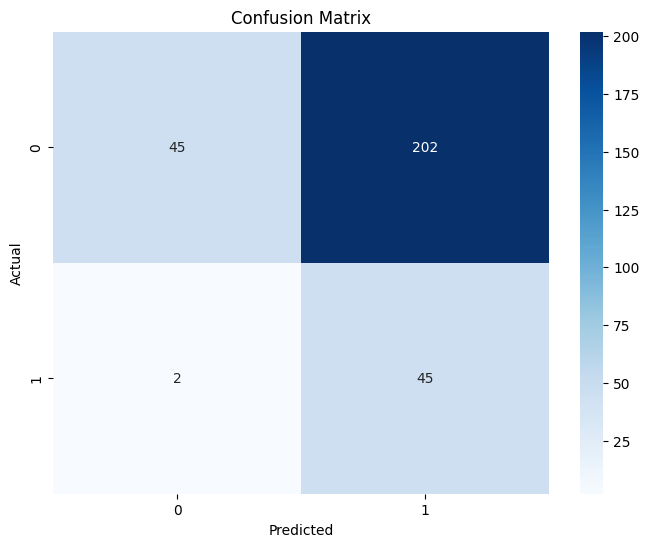

In [83]:
# confusion metrics
cm = confusion_matrix(y_test_binary, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Saving The Model**

In [84]:
import joblib

In [85]:
# Saving the best model and preprocessed objects
joblib.dump(best_model, 'attrition_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!
